### **What Are Word Embeddings?**


Word embeddings are dense vector representations of words where words with similar meanings are located close to each other in vector space.

In simple terms:

Words → Converted into numbers

Numbers → Capture meaning

Similar words → Similar vectors

**Core Idea Behind Word Embeddings**

The main principle:

Words that appear in similar contexts tend to have similar meanings.

Example:

“King” and “Queen” appear in similar contexts.

So their vectors will be close.

This idea is based on the Distributional Hypothesis in linguistics.

**Properties of Word Embeddings**

* Dense vectors (low dimensional)

* Learned automatically from data

* Capture semantic similarity

* Capture relationships between words

**How Word Embeddings Are Learned**

Word embeddings are learned using neural networks.

A famous model is **Word2Vec**

Word2Vec has two architectures:

🔹 CBOW (Continuous Bag of Words): Predict target word from surrounding context.

🔹 Skip-gram: Predict surrounding words from target word.

**Important Hyperparameters**

**1. vector_size**

* Dimension of embedding.
* Example: 50, 100, 300.

* Higher dimension → more expressive but more computation

**2. window**

* Context window size.
* If window = 2: Look 2 words left and right.

**3. min_count**

* Ignore rare words.

**4. sg parameter**

* sg = 0 → CBOW
* sg = 1 → Skip-gram

Now let’s implement Word2Vec and see how words are converted into vectors in practice.

Step 1: Install Libraries

In [ ]:
pip install gensim nltk scikit-learn matplotlib


Step 2: Import Libraries

In [ ]:
import nltk
import string
import numpy as np
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

nltk.download('punkt')
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


Sample Text Data

In [16]:
text = """
Machine learning is fascinating.
I love studying machine learning.
Deep learning is a part of machine learning.
Artificial intelligence and machine learning are closely related.
Coding and learning go hand in hand.
"""

Step 2: Preprocessing

In [17]:
# Convert to lowercase
text = text.lower()

# Remove punctuation
text = text.translate(str.maketrans('', '', string.punctuation))

# Tokenize into sentences
sentences = text.split('\n')

# Tokenize words
tokenized_sentences = [word_tokenize(sentence) for sentence in sentences if sentence]

print("Tokenized Sentences:")
print(tokenized_sentences)

Tokenized Sentences:
[['machine', 'learning', 'is', 'fascinating'], ['i', 'love', 'studying', 'machine', 'learning'], ['deep', 'learning', 'is', 'a', 'part', 'of', 'machine', 'learning'], ['artificial', 'intelligence', 'and', 'machine', 'learning', 'are', 'closely', 'related'], ['coding', 'and', 'learning', 'go', 'hand', 'in', 'hand']]


Step 3: Train Word2Vec Model

In [10]:
model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=50,   # dimension of word vectors
    window=3,         # context window size
    min_count=1,      # include all words
    workers=4
)

print("\nVocabulary:")
print(model.wv.index_to_key)


Vocabulary:
['learning', 'machine', 'hand', 'and', 'is', 'in', 'go', 'coding', 'related', 'closely', 'are', 'intelligence', 'artificial', 'of', 'part', 'a', 'deep', 'studying', 'love', 'i', 'fascinating']


Step 4: Get Word Vector

In [11]:
word = "machine"
print(f"\nVector for '{word}':")
print(model.wv[word])


Vector for 'machine':
[-0.0163283   0.00899547 -0.00828088  0.00164846  0.01700418 -0.00892507
  0.0090421  -0.01357965 -0.00710467  0.01880744 -0.00315974  0.00064516
 -0.00828937 -0.01537414 -0.00302003  0.00493861 -0.00177944  0.01107507
 -0.00548681  0.00451771  0.01091603  0.01669575 -0.00290194 -0.01841754
  0.00874236  0.00114527  0.01489014 -0.00162524 -0.00528379 -0.01751216
 -0.00170802  0.00565455  0.01080865  0.01410387 -0.01140691  0.00371596
  0.01218183 -0.00959634 -0.00621732  0.01360228  0.00326838  0.00037646
  0.00694264  0.00043996  0.01925143  0.01012234 -0.01784148 -0.01408971
  0.00180675  0.01278571]


Most similar Words

In [12]:
print("\nWords similar to 'learning':")
print(model.wv.most_similar("learning"))


Words similar to 'learning':
[('love', 0.2705654501914978), ('part', 0.21057100594043732), ('intelligence', 0.1670495718717575), ('of', 0.150198832154274), ('coding', 0.13204392790794373), ('hand', 0.1266983449459076), ('closely', 0.0998455360531807), ('fascinating', 0.07064189016819), ('deep', 0.059367649257183075), ('studying', 0.04979120194911957)]


Step 5: Cosine Similarity

In [13]:
similarity = model.wv.similarity("machine", "learning")
print("\nSimilarity between 'machine' and 'learning':")
print(similarity)



Similarity between 'machine' and 'learning':
0.042375017


Step 6: Word Vector Visualisation

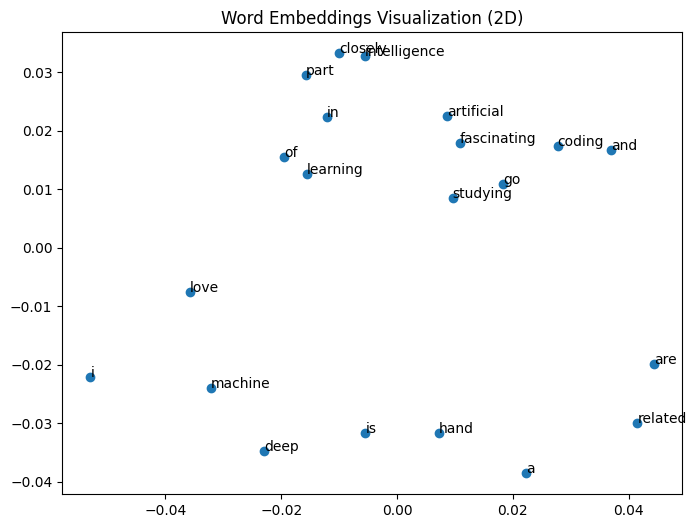

In [14]:
words = model.wv.index_to_key
word_vectors = model.wv[words]

# Reduce dimensions to 2D
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(word_vectors)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(reduced_vectors[i, 0], reduced_vectors[i, 1]))

plt.title("Word Embeddings Visualization (2D)")
plt.show()

**Why Word2Vec Works?**

Works because of:

Distributional Hypothesis:

Words that appear in similar contexts have similar meanings.

Over many training examples, the network adjusts vectors so that:

* Similar context → similar embeddings

* Related words → small cosine distance

**Limitations of Word2Vec**

* Important to mention this before moving to modern models.

* Static embeddings
One word → One vector

* Cannot handle polysemy well
 Example:
“bank” → same vector for river bank and financial bank

* Requires large corpus for good quality

That’s why contextual models like BERT were introduced.